<a href="https://colab.research.google.com/github/MahendraVarma17/internship_projects/blob/main/Predictive_Student_Risk_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import warnings
warnings.filterwarnings("ignore")

In [25]:
df = pd.read_csv("/content/realistic_student_risk_dataset.csv")
df.head()

,Student_ID,Attendance_Percentage,Assessment_Score,Assignment_Completion_Rate,Login_Frequency,Study_Hours,Activity_Count,Communication_Score,Course_Progress_Percentage,Late_Submissions,Previous_Backlogs,Risk_Category
0,S0001,62.2,57.7,73.6,14.0,4.0,60.0,56.6,56.7,2.0,2.0,Medium Risk
1,S0002,91.1,100.0,86.6,20.0,19.0,46.0,79.3,92.3,3.0,0.0,Low Risk
2,S0003,57.5,32.9,65.5,13.0,19.0,78.0,52.3,87.6,1.0,3.0,Medium Risk
3,S0004,70.2,63.9,49.7,11.0,9.0,61.0,54.2,97.4,2.0,0.0,High Risk
4,S0005,91.5,66.3,82.2,27.0,10.0,80.0,94.2,83.3,3.0,2.0,Medium Risk


In [26]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1512, 12)


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  1512 non-null   object 
 1   Attendance_Percentage       1509 non-null   float64
 2   Assessment_Score            1510 non-null   float64
 3   Assignment_Completion_Rate  1509 non-null   float64
 4   Login_Frequency             1508 non-null   float64
 5   Study_Hours                 1510 non-null   float64
 6   Activity_Count              1507 non-null   float64
 7   Communication_Score         1508 non-null   float64
 8   Course_Progress_Percentage  1510 non-null   float64
 9   Late_Submissions            1508 non-null   float64
 10  Previous_Backlogs           1509 non-null   float64
 11  Risk_Category               1512 non-null   object 
dtypes: float64(10), object(2)
memory usage: 141.9+ KB


In [28]:
df.isnull().sum()

,0
Student_ID,0
Attendance_Percentage,3
Assessment_Score,2
Assignment_Completion_Rate,3
Login_Frequency,4
Study_Hours,2
Activity_Count,5
Communication_Score,4
Course_Progress_Percentage,2
Late_Submissions,4


In [29]:
df.duplicated().sum()

np.int64(12)

In [30]:
df = df.drop_duplicates()
print("Duplicates Removed Successfully")
print("New Shape:", df.shape)

Duplicates Removed Successfully
New Shape: (1500, 12)


In [31]:
df.describe()

,Attendance_Percentage,Assessment_Score,Assignment_Completion_Rate,Login_Frequency,Study_Hours,Activity_Count,Communication_Score,Course_Progress_Percentage,Late_Submissions,Previous_Backlogs
count,1497.000000,1498.000000,1497.000000,1496.000000,1498.000000,1495.000000,1496.000000,1498.000000,1496.000000,1497.000000
mean,66.876553,61.984646,64.894188,15.389706,12.654206,56.717057,63.025134,63.297597,3.209225,1.814963
std,20.918964,21.793741,22.307111,6.712331,5.889252,25.561529,22.884406,22.931317,2.557893,1.402286
min,5.000000,5.000000,10.000000,0.000000,1.000000,1.000000,10.000000,10.000000,0.000000,0.000000
25%,51.800000,46.250000,48.400000,11.000000,9.000000,39.000000,47.200000,47.625000,1.000000,1.000000
50%,68.000000,62.800000,65.200000,15.000000,13.000000,57.000000,63.200000,63.800000,3.000000,2.000000
75%,83.300000,78.500000,82.100000,20.000000,17.000000,75.000000,80.600000,80.750000,5.000000,3.000000
max,100.000000,100.000000,100.000000,45.000000,30.000000,120.000000,100.000000,100.000000,12.000000,6.000000


In [32]:
df["Risk_Category"].value_counts()

,count
Risk_Category,
High Risk,671
Medium Risk,483
Low Risk,346


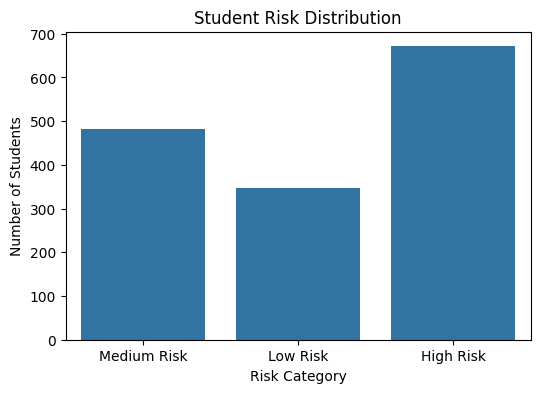

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Risk_Category")
plt.title("Student Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Students")
plt.show()

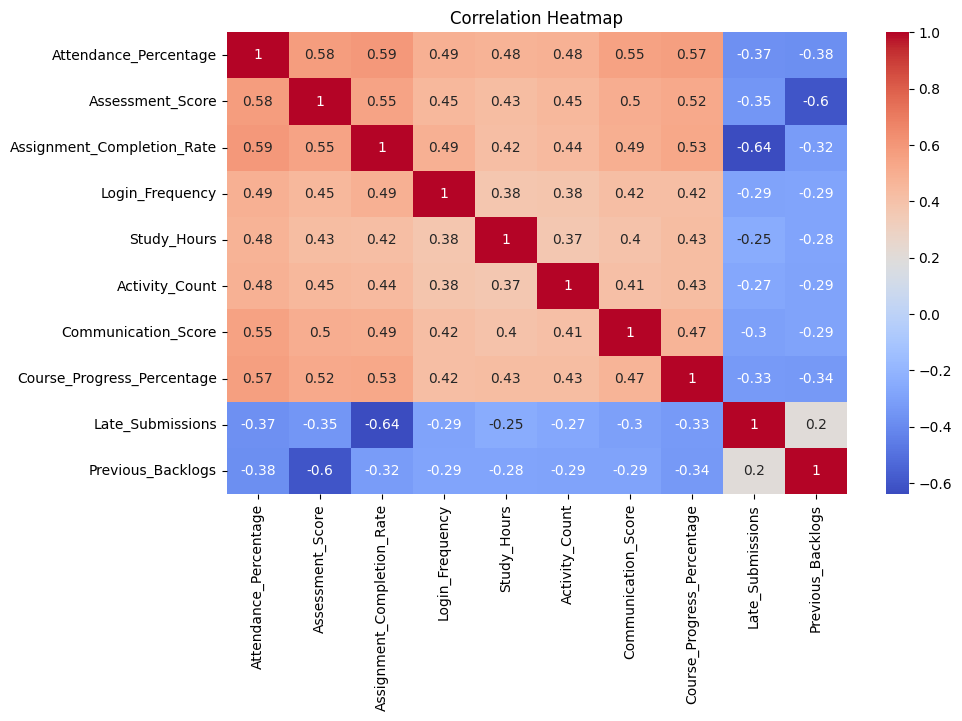

In [34]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop("Student_ID", axis=1).select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [35]:
encoder = LabelEncoder()
df["Risk_Category_Encoded"] = encoder.fit_transform(df["Risk_Category"])
print(encoder.classes_)
df.head()

['High Risk' 'Low Risk' 'Medium Risk']


,Student_ID,Attendance_Percentage,Assessment_Score,Assignment_Completion_Rate,Login_Frequency,Study_Hours,Activity_Count,Communication_Score,Course_Progress_Percentage,Late_Submissions,Previous_Backlogs,Risk_Category,Risk_Category_Encoded
0,S0001,62.2,57.7,73.6,14.0,4.0,60.0,56.6,56.7,2.0,2.0,Medium Risk,2
1,S0002,91.1,100.0,86.6,20.0,19.0,46.0,79.3,92.3,3.0,0.0,Low Risk,1
2,S0003,57.5,32.9,65.5,13.0,19.0,78.0,52.3,87.6,1.0,3.0,Medium Risk,2
3,S0004,70.2,63.9,49.7,11.0,9.0,61.0,54.2,97.4,2.0,0.0,High Risk,0
4,S0005,91.5,66.3,82.2,27.0,10.0,80.0,94.2,83.3,3.0,2.0,Medium Risk,2


In [36]:
X = df.drop(["Student_ID", "Risk_Category", "Risk_Category_Encoded"], axis=1)
y = df["Risk_Category_Encoded"]
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1500, 10)
Target Shape: (1500,)


In [45]:
from sklearn.impute import SimpleImputer
import numpy as np

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

nan_count_imputed = np.isnan(X_imputed).sum()
if nan_count_imputed > 0:
    print(f"Warning: {nan_count_imputed} NaNs found in X_imputed after imputation!")
else:
    print("X_imputed is NaN-free.")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

nan_count_scaled = np.isnan(X_scaled).sum()
if nan_count_scaled > 0:
    print(f"Warning: {nan_count_scaled} NaNs found in X_scaled after scaling!")
else:
    print("X_scaled is NaN-free.")

print("Feature Imputation and Scaling Completed")

Feature Imputation and Scaling Completed


In [46]:
X_train, X_test, y_train, y_test = train_test_split( X_scaled,y, test_size=0.3,random_state=42,stratify=y)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1050, 10)
Testing Data: (450, 10)


In [43]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [47]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [48]:
svm_model = SVC( probability=True,random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
print("SVM Model Trained Successfully")

SVM Model Trained Successfully


In [49]:
def evaluate_model(model_name, y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [50]:
results = []

results.append(evaluate_model("Random Forest", y_test, rf_pred))
results.append(evaluate_model("Gradient Boosting", y_test, gb_pred))
results.append(evaluate_model("SVM", y_test, svm_pred))

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.777778,0.779485,0.777778,0.777922
1,Gradient Boosting,0.766667,0.773607,0.766667,0.768733
2,SVM,0.811111,0.811040,0.811111,0.810302


In [52]:
print("===== RANDOM FOREST =====")
print(classification_report(y_test, rf_pred))

print("\n===== GRADIENT BOOSTING =====")
print(classification_report(y_test, gb_pred))

print("\n===== SVM =====")
print(classification_report(y_test, svm_pred))

===== RANDOM FOREST =====
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       201
           1       0.83      0.74      0.78       104
           2       0.65      0.68      0.66       145

    accuracy                           0.78       450
   macro avg       0.78      0.76      0.77       450
weighted avg       0.78      0.78      0.78       450


===== GRADIENT BOOSTING =====
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       201
           1       0.82      0.72      0.77       104
           2       0.63      0.70      0.67       145

    accuracy                           0.77       450
   macro avg       0.77      0.75      0.76       450
weighted avg       0.77      0.77      0.77       450


===== SVM =====
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       201
           1       0.84      0.75      0.79       104
 

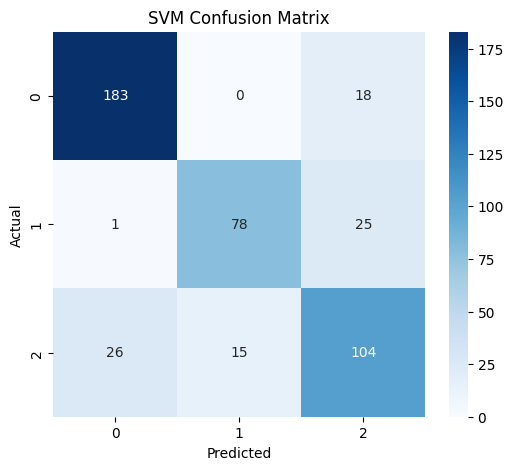

In [53]:
cm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [54]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
feature_importance

,Feature,Importance
1,Assessment_Score,0.186528
2,Assignment_Completion_Rate,0.160028
0,Attendance_Percentage,0.141954
7,Course_Progress_Percentage,0.114305
6,Communication_Score,0.079850
5,Activity_Count,0.068372
8,Late_Submissions,0.067056
4,Study_Hours,0.062926
3,Login_Frequency,0.061913
9,Previous_Backlogs,0.057068


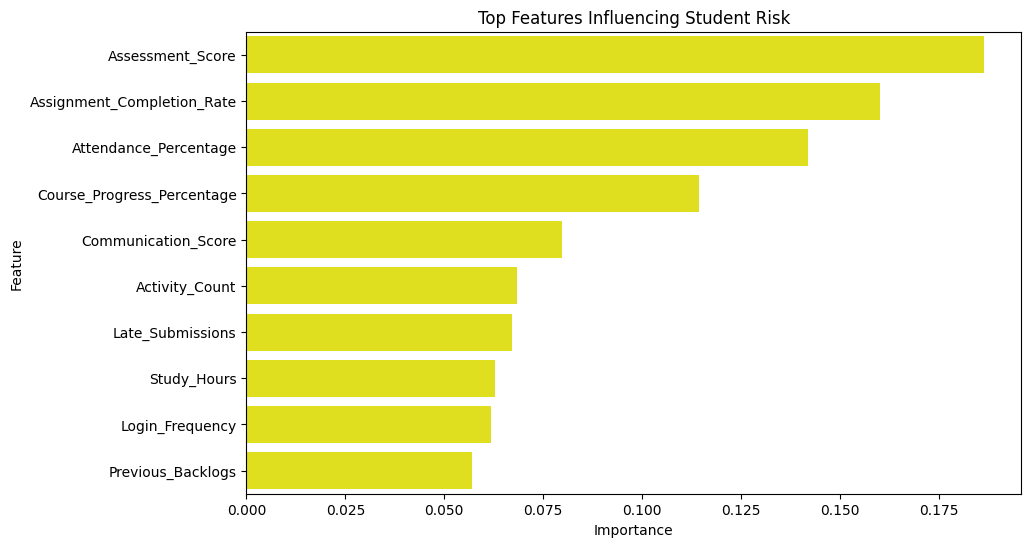

In [57]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature',
    color='yellow'
)
plt.title("Top Features Influencing Student Risk")

plt.show()

In [58]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_test_bin = label_binarize(y_test, classes=[0,1,2])

rf_prob = rf_model.predict_proba(X_test)
gb_prob = gb_model.predict_proba(X_test)
svm_prob = svm_model.predict_proba(X_test)

rf_auc = roc_auc_score(y_test_bin, rf_prob, multi_class='ovr')
gb_auc = roc_auc_score(y_test_bin, gb_prob, multi_class='ovr')
svm_auc = roc_auc_score(y_test_bin, svm_prob, multi_class='ovr')

print("Random Forest ROC-AUC:", rf_auc)
print("Gradient Boosting ROC-AUC:", gb_auc)
print("SVM ROC-AUC:", svm_auc)

Random Forest ROC-AUC: 0.8978427610564035
Gradient Boosting ROC-AUC: 0.8933631185938783
SVM ROC-AUC: 0.9182181333135734


<Figure size 800x500 with 0 Axes>

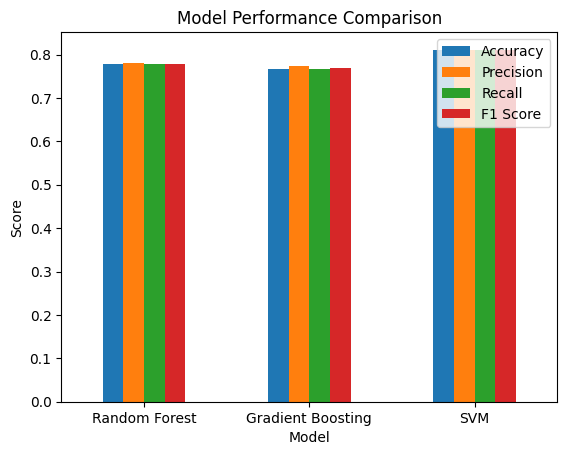

In [59]:
plt.figure(figsize=(8,5))
results_df.set_index("Model")[
    ["Accuracy","Precision","Recall","F1 Score"]
].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

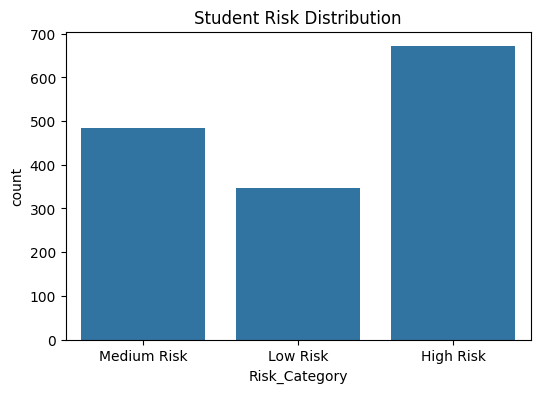

In [60]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x="Risk_Category"
)
plt.title("Student Risk Distribution")
plt.show()